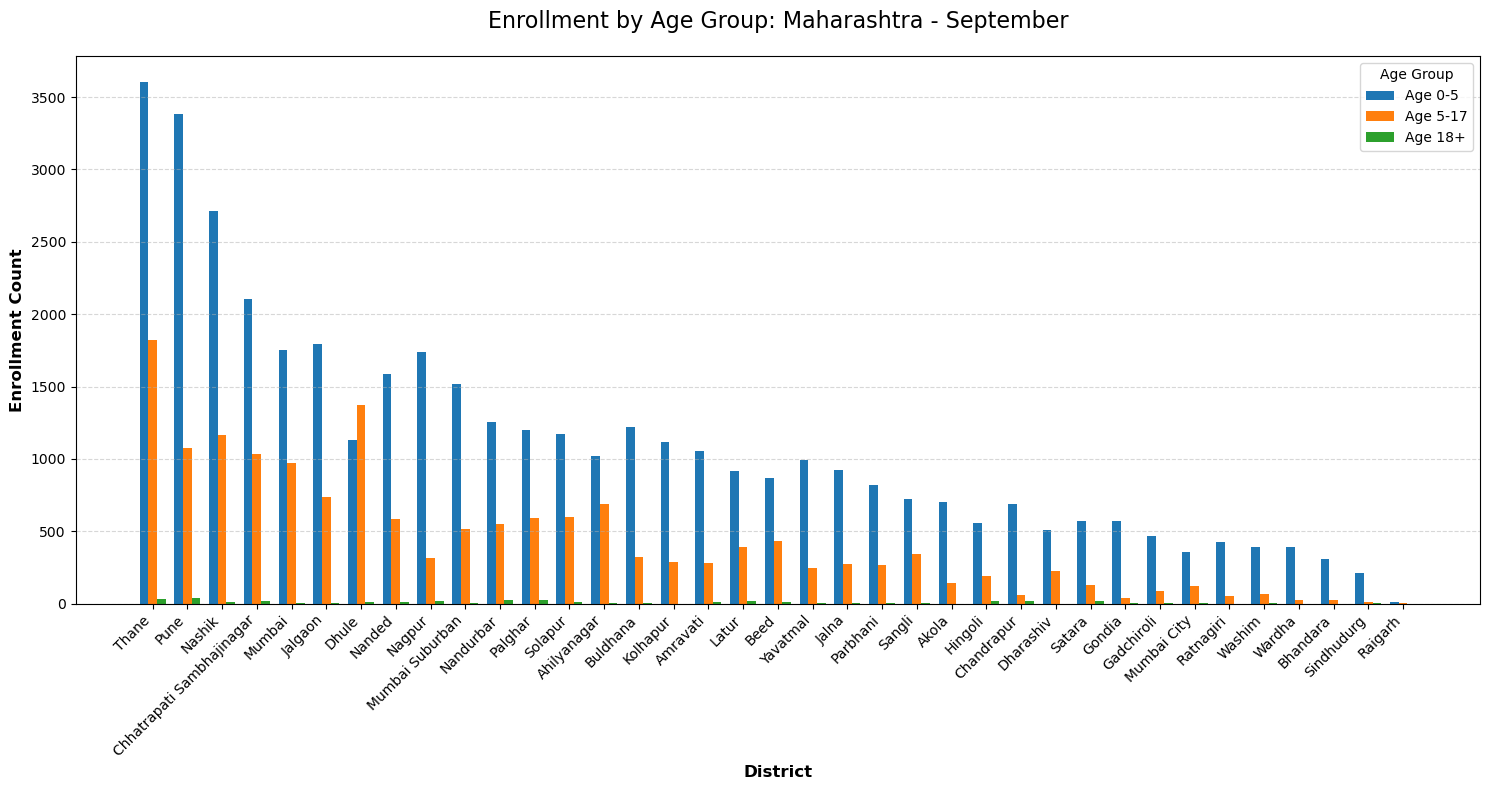

,district,age_0_5,age_5_17,age_18_greater,total_enrollment
0,Thane,3605,1821,30,5456
1,Pune,3383,1076,40,4499
2,Nashik,2715,1165,14,3894
3,Chhatrapati Sambhajinagar,2104,1037,16,3157
4,Mumbai,1751,972,5,2728
5,Jalgaon,1795,736,5,2536
6,Dhule,1130,1374,13,2517
7,Nanded,1589,585,8,2182
8,Nagpur,1740,313,17,2070
9,Mumbai Suburban,1520,518,6,2044


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import calendar

def get_state_district_summary(file_path, state_name, month_number):
    """
    Filters data for a specific state and month, aggregates by district, 
    and sorts by total enrollment.
    """
    # 1. Load Data
    df = pd.read_parquet(file_path)
    
    # Ensure date is datetime
    if not pd.api.types.is_datetime64_any_dtype(df['date']):
        df['date'] = pd.to_datetime(df['date'])
        
    # 2. Filter by State and Month
    # case=False makes it case-insensitive (e.g. "Pune" == "pune")
    mask = (
        # (df['state'].str.lower() == state_name.lower()) & 
        (df['date'].dt.month == month_number)
    )
    filtered_df = df[mask].copy()
    
    if filtered_df.empty:
        print(f"No data found for {state_name} in month {month_number}.")
        return pd.DataFrame()
        
    # 3. Aggregate (Group by District and Sum Age Columns)
    age_cols = ['age_0_5', 'age_5_17', 'age_18_greater']
    summary_df = filtered_df.groupby('district')[age_cols].sum().reset_index()
    
    # 4. Calculate Total for Sorting
    summary_df['total_enrollment'] = summary_df[age_cols].sum(axis=1)
    
    # 5. Sort Descending by Total Enrollment
    summary_df = summary_df.sort_values(by='total_enrollment', ascending=False).reset_index(drop=True)
    # summary_df = summary_df.drop(columns=['total'])
    return summary_df

def plot_district_age_clusters(summary_df, state_name, month_number):
    """
    Plots a clustered bar chart of age groups for each district.
    """
    if summary_df.empty:
        print("Dataframe is empty. Cannot plot.")
        return

    # Get Month Name (e.g., 9 -> "September")
    month_name = calendar.month_name[month_number]
    
    # Prepare Data for Plotting
    districts = summary_df['district']
    x = range(len(districts))
    width = 0.25  # Width of each bar
    
    # Create Figure
    fig, ax = plt.subplots(figsize=(15, 8))
    
    # Plot 3 Bars for each district (Clustered)
    bar1 = ax.bar([i - width for i in x], summary_df['age_0_5'], width, label='Age 0-5', color='#1f77b4')
    bar2 = ax.bar([i for i in x], summary_df['age_5_17'], width, label='Age 5-17', color='#ff7f0e')
    bar3 = ax.bar([i + width for i in x], summary_df['age_18_greater'], width, label='Age 18+', color='#2ca02c')
    
    # Customizing the Plot
    ax.set_xlabel('District', fontsize=12, fontweight='bold')
    ax.set_ylabel('Enrollment Count', fontsize=12, fontweight='bold')
    ax.set_title(f"Enrollment by Age Group: {state_name} - {month_name}", fontsize=16, pad=20)
    
    # Set X-Axis Ticks to be District Names
    ax.set_xticks(x)
    ax.set_xticklabels(districts, rotation=45, ha='right', fontsize=10)
    
    # Add Legend and Grid
    ax.legend(title="Age Group")
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

# --- EXAMPLE USAGE ---
file = "1maha_district.parquet"  # REPLACE with your actual file path

# 1. Get Data
df_summary = get_state_district_summary(file, state_name="Maharashtra", month_number=9)

# 2. Plot Data
plot_district_age_clusters(df_summary, state_name="Maharashtra", month_number=9)

# Optional: View the table
display(df_summary)



In [4]:
# 1. Calculate the Correlation Matrix
correlation_matrix = df_summary[['age_0_5', 'age_5_17']].corr()

# 2. Extract the specific correlation value
correlation_value = correlation_matrix.loc['age_0_5', 'age_5_17']

print(f"Correlation between Age 0-5 and Age 5-17: {correlation_value:.4f}")


Correlation between Age 0-5 and Age 5-17: 0.8636


In [5]:
df_summary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   district          37 non-null     object
 1   age_0_5           37 non-null     int32 
 2   age_5_17          37 non-null     int32 
 3   age_18_greater    37 non-null     int32 
 4   total_enrollment  37 non-null     int64 
dtypes: int32(3), int64(1), object(1)
memory usage: 1.1+ KB


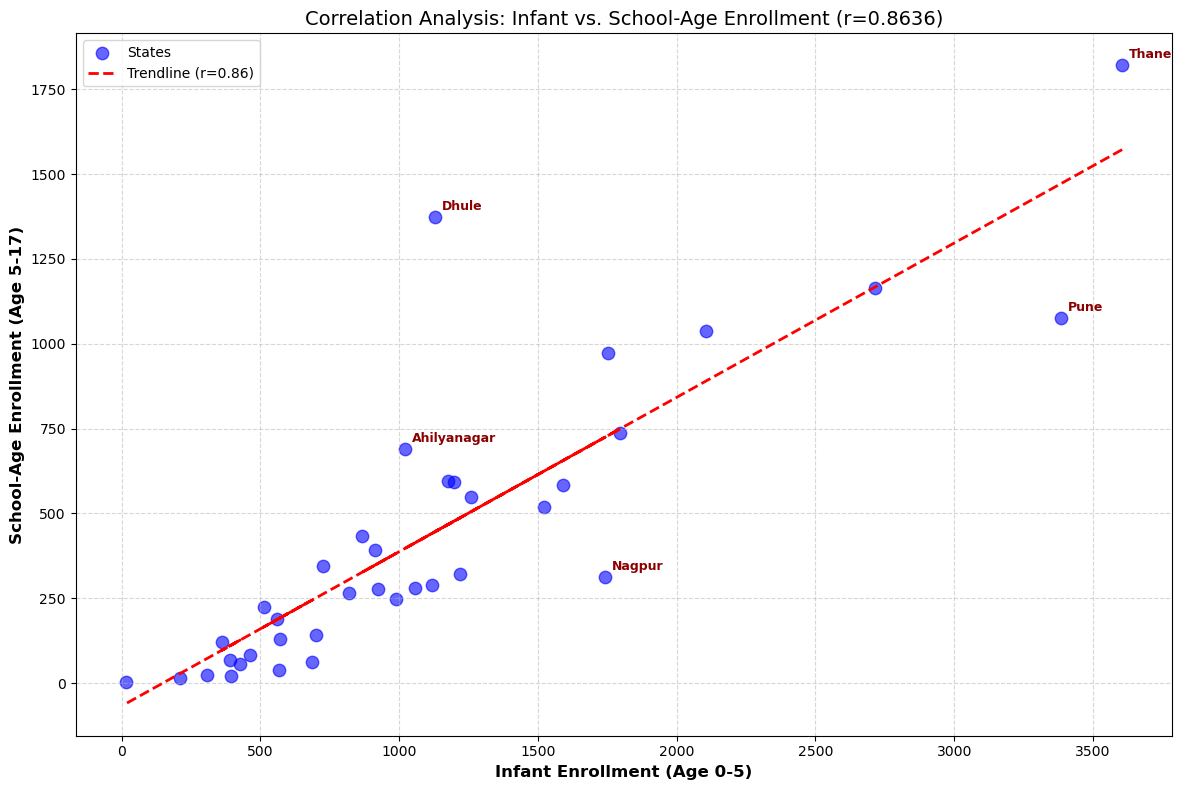

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_correlation_scatter(df):
    """
    Plots a scatter chart between Age 0-5 and Age 5-17 with a trendline and outlier labels.
    """
    # 1. Prepare Data
    x = df['age_0_5']
    y = df['age_5_17']
    states = df['district']

    # 2. Calculate Correlation
    corr = x.corr(y)
    
    # 3. Setup Plot
    plt.figure(figsize=(12, 8))
    
    # Scatter points
    plt.scatter(x, y, color='blue', alpha=0.6, s=80, label='States')
    
    # 4. Add Trendline (Linear Regression)
    # np.polyfit(x, y, 1) returns slope (m) and intercept (b)
    m, b = np.polyfit(x, y, 1)
    plt.plot(x, m*x + b, color='red', linestyle='--', linewidth=2, label=f'Trendline (r={corr:.2f})')
    
    # 5. Identify and Label Outliers
    # We calculate the "distance" of each point from the trendline
    # Predicted Y for each X
    y_pred = m*x + b
    # Residual (Difference between actual Y and predicted Y)
    residuals = np.abs(y - y_pred)
    
    # Define a threshold for labeling (e.g., top 5 furthest states)
    top_outliers = residuals.nlargest(5).index
    
    # Add labels for these outliers
    for i in top_outliers:
        plt.annotate(states[i], 
                     (x[i], y[i]), 
                     xytext=(5, 5), 
                     textcoords='offset points',
                     fontsize=9, 
                     fontweight='bold',
                     color='darkred')

    # 6. Styling
    plt.title(f'Correlation Analysis: Infant vs. School-Age Enrollment (r={corr:.4f})', fontsize=14)
    plt.xlabel('Infant Enrollment (Age 0-5)', fontsize=12, fontweight='bold')
    plt.ylabel('School-Age Enrollment (Age 5-17)', fontsize=12, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# --- USAGE ---
# Assuming 'df' is your dataframe with columns: 'state', 'age_0_5', 'age_5_17'

plot_correlation_scatter(df_summary)
